In [1]:
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv(r"C:\Users\sruth\OneDrive\Desktop\aicte\Task 1\cleaned_student_dataset.csv")
# Quick check
print(df.head())
print(df.info())

  Student_ID           Name Date_of_Birth Gender  Course  Year           City  \
0      S0001  Vihaan Sharma    2005-01-31      M    B.Sc     2  Visakhapatnam   
1      S0002   Saanvi Reddy    2006-09-25      M  B.Tech     1        Chennai   
2      S0003  Krishna Gupta    2002-04-19      M      BA     4        Chennai   
3      S0004     Myra Mehta    2005-02-13      M    B.Sc     4        Kolkata   
4      S0005   Ishaan Verma    2004-05-31      F  B.Tech     1          Delhi   

                        Email  Age  
0  vihaan.sharma1@example.com   21  
1   saanvi.reddy2@example.com   19  
2  krishna.gupta3@example.com   23  
3     myra.mehta4@example.com   21  
4   ishaan.verma5@example.com   21  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Student_ID     1000 non-null   object
 1   Name           1000 non-null   object
 2   Date_of_B

In [5]:
print(df.groupby('Year')['Age'].describe())

      count       mean       std   min   25%   50%   75%   max
Year                                                          
1     248.0  20.467742  1.690342  18.0  19.0  20.0  22.0  24.0
2     264.0  20.772727  1.726954  18.0  19.0  21.0  22.0  24.0
3     247.0  20.647773  1.725415  18.0  19.0  21.0  22.0  24.0
4     241.0  20.763485  1.776606  18.0  19.0  21.0  22.0  24.0


In [6]:
year1 = df[df['Year'] == 1]['Age']
year4 = df[df['Year'] == 4]['Age']

In [7]:
from scipy.stats import shapiro

print("Year 1:", shapiro(year1))
print("Year 4:", shapiro(year4))

Year 1: ShapiroResult(statistic=0.9262885451316833, pvalue=9.057942729207014e-10)
Year 4: ShapiroResult(statistic=0.9215070009231567, pvalue=5.544470993434913e-10)


In [8]:
t_stat, p_value = ttest_ind(year1, year4)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: -1.8862482143912198
P-value: 0.059856258142557954


In [9]:
alpha = 0.05

if p_value < alpha:
    print("Reject Null Hypothesis (Significant Difference)")
else:
    print("Fail to Reject Null Hypothesis (No Significant Difference)")

Fail to Reject Null Hypothesis (No Significant Difference)


In [10]:
print("Mean Age Year 1:", np.mean(year1))
print("Mean Age Year 4:", np.mean(year4))

Mean Age Year 1: 20.467741935483872
Mean Age Year 4: 20.763485477178424


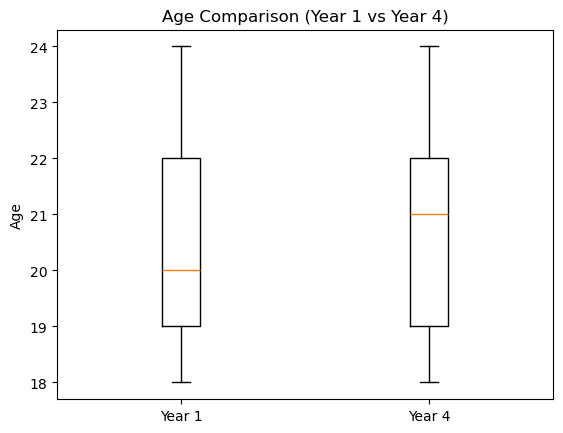

In [11]:
plt.boxplot([year1, year4], labels=['Year 1', 'Year 4'])
plt.title("Age Comparison (Year 1 vs Year 4)")
plt.ylabel("Age")
plt.show()

In [12]:
import scipy.stats as stats

diff_mean = np.mean(year4) - np.mean(year1)
se = np.sqrt(np.var(year1)/len(year1) + np.var(year4)/len(year4))

ci = stats.norm.interval(0.95, loc=diff_mean, scale=se)

print("95% Confidence Interval:", ci)

95% Confidence Interval: (-0.011146919313225145, 0.6026340027023296)
